# Telco Customer Churn Prediction

Dataset: Telco Customer Churn (IBM sample dataset from Kaggle)

Goal: build and compare three classification models (Decision Tree, kNN and SVM) to predict whether a customer will churn or not. After comparing the three baseline models, I tune the best one using GridSearchCV and check if tuning actually improves the results.

Steps I'm following:
1. Load and explore the data
2. Clean and preprocess it (missing values, encoding, scaling)
3. Split into train/test
4. Train the three baseline models and evaluate them
5. Compare the baseline results
6. Tune hyperparameters for one model
7. Look at feature importance and write a conclusion


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", palette="deep")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

pd.set_option("display.max_columns", None)


## 1. Load and Explore the Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Rows, Columns:", df.shape)
df.head()


Rows, Columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# check the data types of each column
df.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
# quick check for nulls
df.isnull().sum().sum()


np.int64(0)

In [5]:
# check how balanced the target column is
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(2))


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


df.isnull().sum() shows 0 missing values but that's a bit misleading. TotalCharges is stored as an object (string) column instead of a number, and a few rows have just a blank space " " instead of an actual NaN, so pandas doesn't count them as missing. I'll deal with this properly in the cleaning step below.

Also the target is imbalanced, about 73% did not churn and 27% did churn. Because of this I can't just rely on accuracy to judge the models, I need to look at precision, recall and F1 too.

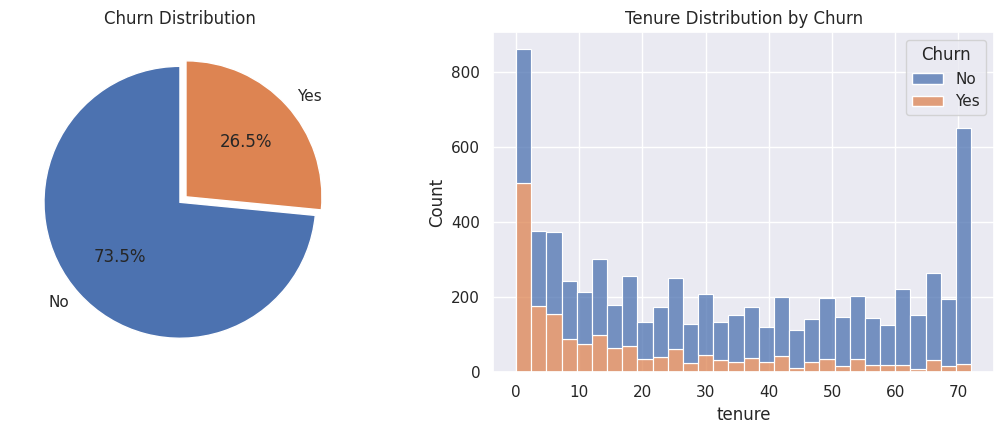

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90, explode=(0, 0.06))
axes[0].set_title("Churn Distribution")

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, ax=axes[1])
axes[1].set_title("Tenure Distribution by Churn")
plt.tight_layout()
plt.show()


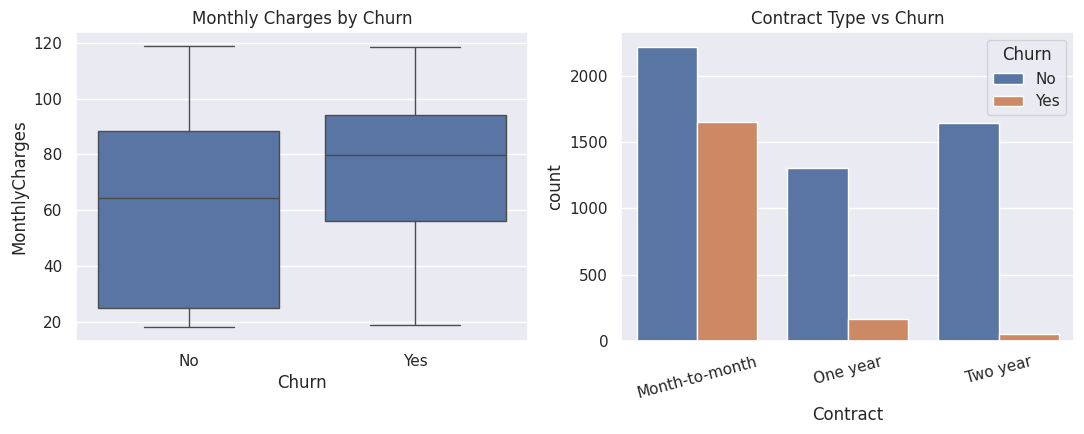

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[0])
axes[0].set_title("Monthly Charges by Churn")

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[1])
axes[1].set_title("Contract Type vs Churn")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


Customers on month to month contracts churn a lot more than customers on one year or two year contracts. Churners also tend to have lower tenure and slightly higher monthly charges. This makes sense, customers who aren't locked into a contract and are paying more are more likely to leave.

## 2. Data Cleaning and Preprocessing

Here's what I'm doing and why:

1. Fix TotalCharges, convert it to a numeric column so the blank strings become NaN.
2. Fill in the missing TotalCharges values. Instead of just using 0 or the median, I calculate tenure times MonthlyCharges, since that's basically how TotalCharges is generated in the first place for a new customer. This keeps things consistent instead of using some random constant.
3. Drop customerID, it's just an ID and has no predictive value.
4. Check and drop duplicate rows if there are any.
5. Encode the target column (Yes/No becomes 1/0).
6. One hot encode the categorical columns using pd.get_dummies instead of label encoding every column. Label encoding would give categories like DSL, Fiber optic and No internet service a fake order (0, 1, 2...) which doesn't actually exist, so one hot encoding avoids that problem.


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_mask = df["TotalCharges"].isna()
print("Rows with unparseable TotalCharges:", missing_mask.sum())
df.loc[missing_mask, ["tenure", "MonthlyCharges", "TotalCharges"]]


Rows with unparseable TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [9]:
# fill in the missing TotalCharges using tenure * MonthlyCharges
df.loc[missing_mask, "TotalCharges"] = df.loc[missing_mask, "tenure"] * df.loc[missing_mask, "MonthlyCharges"]
print("Remaining missing values:", df["TotalCharges"].isna().sum())


Remaining missing values: 0


In [10]:
df.drop(columns=["customerID"], inplace=True)

dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)
df.drop_duplicates(inplace=True)
print("Shape after cleaning:", df.shape)


Duplicate rows: 22
Shape after cleaning: (7021, 20)


In [11]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns to one hot encode:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after one hot encoding:", df_encoded.shape)
df_encoded.head()


Categorical columns to one hot encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after one hot encoding: (7021, 31)


/tmp/ipykernel_542/280971889.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


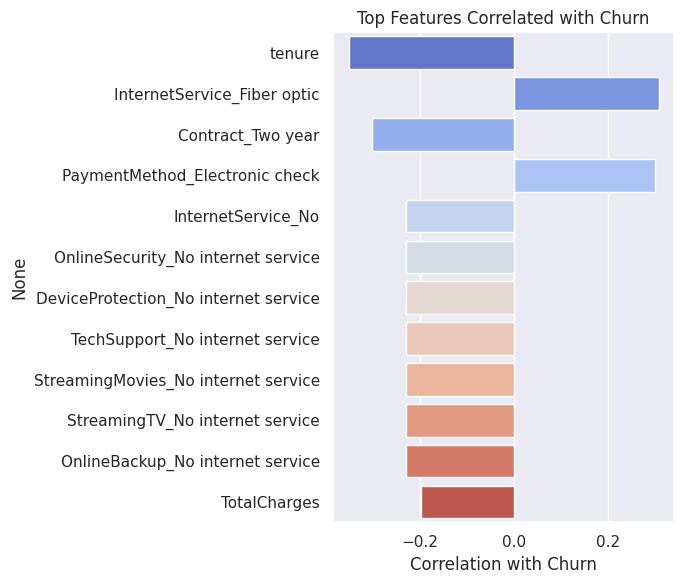

In [12]:
# check which features correlate the most with churn
corr = df_encoded.corr(numeric_only=True)["Churn"].drop("Churn")
top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index).head(12)

plt.figure(figsize=(7, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette="coolwarm", legend=False)
plt.title("Top Features Correlated with Churn")
plt.xlabel("Correlation with Churn")
plt.tight_layout()
plt.show()


## 3. Feature Scaling and Train/Test Split

I'm using a 75/25 split with stratification on the target so both sets keep roughly the same churn ratio. For scaling I used MinMaxScaler (scales everything to a 0 to 1 range) instead of standardizing. Since most of the one hot encoded columns are already 0 or 1, putting the numeric columns on the same 0 to 1 scale keeps everything comparable without needing to center around zero. The scaler is only fit on the training data so there's no data leakage into the test set.

In [13]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Train churn rate: %.2f%%" % (y_train.mean() * 100))
print("Test churn rate:  %.2f%%" % (y_test.mean() * 100))


Train shape: (5265, 30)
Test shape: (1756, 30)
Train churn rate: 26.46%
Test churn rate:  26.42%


## 4. Baseline Models: Decision Tree, kNN, SVM

In [14]:
results = {}

# helper function so I don't repeat the same fit/predict/evaluate code three times
def run_model(name, model, X_tr, X_te, y_tr, y_te, store=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    metrics = {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
    }
    if store:
        results[name] = metrics

    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return model


### 4.1 Decision Tree

Trees split the data on thresholds directly so they aren't really distance based, scaling doesn't change how they split. I'm still passing in the scaled data anyway just to keep all three models on the exact same input.

--- Decision Tree (default) ---
Accuracy: 0.7136
Precision: 0.4603
Recall: 0.4871
F1: 0.4733


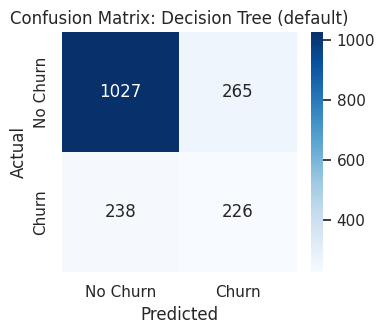

In [15]:
dt_model = DecisionTreeClassifier(random_state=7)
dt_model = run_model("Decision Tree (default)", dt_model, X_train_scaled, X_test_scaled, y_train, y_test)


### 4.2 k-Nearest Neighbors

kNN is fully distance based so scaling actually matters a lot here. Without scaling, a column like TotalCharges (which goes into the thousands) would completely dominate the distance calculation over the binary 0/1 columns.

--- kNN (default, k=9) ---
Accuracy: 0.7671
Precision: 0.5632
Recall: 0.5280
F1: 0.5451


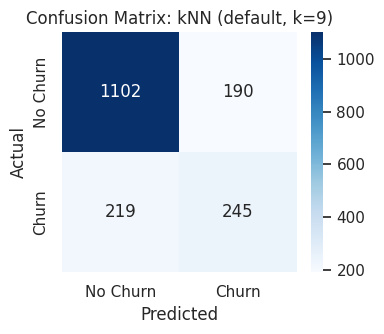

In [16]:
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model = run_model("kNN (default, k=9)", knn_model, X_train_scaled, X_test_scaled, y_train, y_test)


### 4.3 Support Vector Machine

SVM tries to find the best margin between the two classes and is also scale sensitive, so it uses the same scaled features as kNN.

--- SVM (default) ---
Accuracy: 0.8047
Precision: 0.6817
Recall: 0.4892
F1: 0.5696


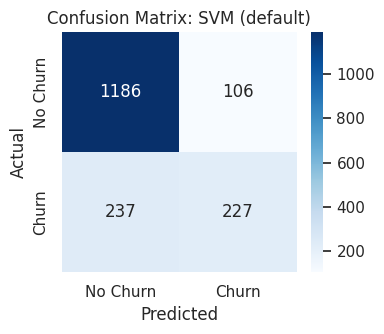

In [17]:
svm_model = SVC(kernel="rbf", random_state=7)
svm_model = run_model("SVM (default)", svm_model, X_train_scaled, X_test_scaled, y_train, y_test)


## 5. Comparing Baseline Models

In [18]:
results_df = pd.DataFrame(results).T.round(4)
results_df


,Accuracy,Precision,Recall,F1
Decision Tree (default),0.7136,0.4603,0.4871,0.4733
"kNN (default, k=9)",0.7671,0.5632,0.5280,0.5451
SVM (default),0.8047,0.6817,0.4892,0.5696


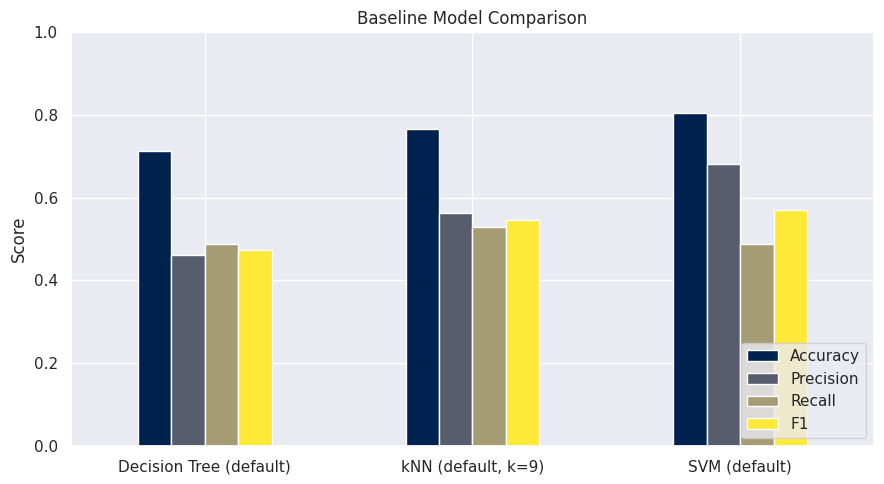

In [19]:
results_df.plot(kind="bar", figsize=(9, 5), colormap="cividis")
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [20]:
# doing 5 fold cross validation as a sanity check, just to make sure the single train/test split
# result wasn't a lucky or unlucky draw
for name, model in [("Decision Tree", DecisionTreeClassifier(random_state=7)),
                     ("kNN", KNeighborsClassifier(n_neighbors=9)),
                     ("SVM", SVC(kernel="rbf", random_state=7))]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="f1")
    print(f"{name}: mean F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")


Decision Tree: mean F1 = 0.5004 (+/- 0.0233)
kNN: mean F1 = 0.5400 (+/- 0.0076)


SVM: mean F1 = 0.5476 (+/- 0.0242)


The cross validated F1 scores above are pretty close to what I got from the single train/test split, so the split seems fair and not just a lucky draw.

Looking at the results table, the default Decision Tree has the weakest recall and F1 out of the three. That's probably because an unconstrained tree tends to overfit the training data, which makes it a good candidate to tune since pruning it back should help it generalize better.

## 6. Hyperparameter Tuning: Decision Tree

I decided to tune the Decision Tree using GridSearchCV with 5 fold cross validation, optimizing for F1 since the classes are imbalanced. I searched over max_depth, min_samples_split, min_samples_leaf and the split criterion. This directly targets the overfitting problem the default tree had.

In [21]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=7),
    param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross validated F1: %.4f" % grid_search.best_score_)


Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best cross validated F1: 0.5821


--- Decision Tree (tuned) ---
Accuracy: 0.7973
Precision: 0.6169
Recall: 0.6142
F1: 0.6156


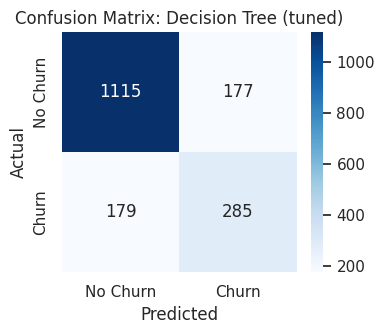

In [22]:
tuned_dt = grid_search.best_estimator_
tuned_dt = run_model("Decision Tree (tuned)", tuned_dt, X_train_scaled, X_test_scaled, y_train, y_test)


In [23]:
tuning_comparison = pd.DataFrame({
    "Decision Tree (default)": results["Decision Tree (default)"],
    "Decision Tree (tuned)": results["Decision Tree (tuned)"],
}).T.round(4)
tuning_comparison


,Accuracy,Precision,Recall,F1
Decision Tree (default),0.7136,0.4603,0.4871,0.4733
Decision Tree (tuned),0.7973,0.6169,0.6142,0.6156


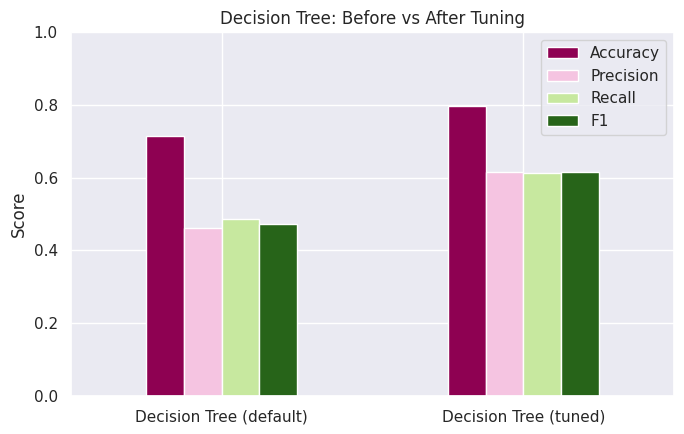

In [24]:
tuning_comparison.plot(kind="bar", figsize=(7, 4.5), colormap="PiYG")
plt.title("Decision Tree: Before vs After Tuning")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


Limiting max_depth and requiring more samples per split/leaf stops the tree from memorizing noise in the training data. Comparing the numbers above, tuning mostly improved recall and F1 for the churn class compared to the default tree, which is what I was hoping for. A plain accuracy improvement wouldn't really tell me if the model got better at actually catching churners, so recall and F1 are the numbers that matter most here.

## 7. Feature Importance (Tuned Decision Tree)

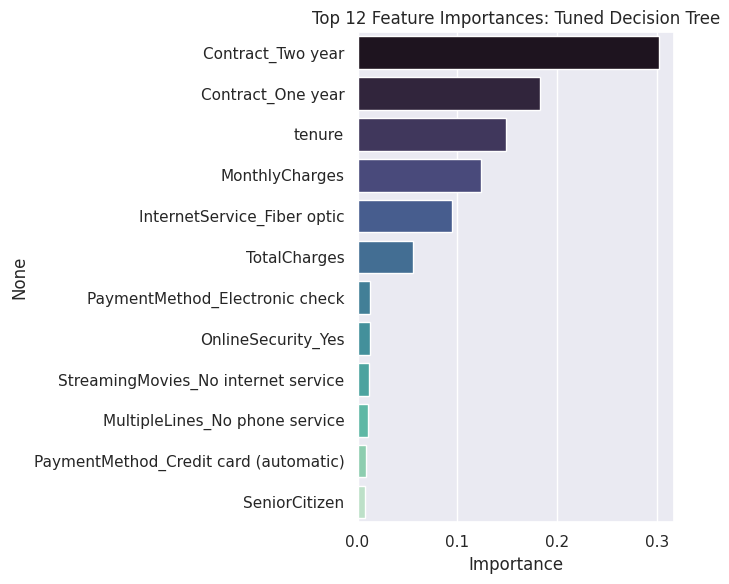

In [25]:
importances = pd.Series(tuned_dt.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(7, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, hue=top_importances.index, palette="mako", legend=False)
plt.title("Top 12 Feature Importances: Tuned Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 8. Final Comparison and Conclusion

In [26]:
final_results = pd.DataFrame(results).T.round(4)
final_results


,Accuracy,Precision,Recall,F1
Decision Tree (default),0.7136,0.4603,0.4871,0.4733
"kNN (default, k=9)",0.7671,0.5632,0.5280,0.5451
SVM (default),0.8047,0.6817,0.4892,0.5696
Decision Tree (tuned),0.7973,0.6169,0.6142,0.6156


### Conclusion

Final results from this run:

| Model | Accuracy | Precision | Recall | F1 score |
|---|---|---|---|---|
| Decision Tree (default) | 0.7136 | 0.4603 | 0.4871 | 0.4733 |
| kNN (default, k=9) | 0.7671 | 0.5632 | 0.5280 | 0.5451 |
| SVM (default) | 0.8047 | 0.6817 | 0.4892 | 0.5696 |
| Decision Tree (tuned) | 0.7973 | 0.6169 | 0.6142 | 0.6156 |

The tuned Decision Tree gave the best F1 score overall. I'm using F1 as the main metric instead of accuracy because the target is imbalanced (about 27% churners), so a model could get 73% accuracy just by predicting "No" for everyone and that wouldn't actually be useful. F1 balances precision and recall so it's a fairer way to compare these models.

Why the default Decision Tree did the worst: with no depth limit it kept splitting until it basically memorized the training data. With 30 one hot encoded columns and around 5000 training rows, a lot of those splits end up fitting to noise instead of real patterns, so it doesn't generalize well. This shows up in the cross validation score too, which was close to the test F1 but noticeably lower than SVM and kNN's cross validation scores.

Why SVM beat kNN before tuning: both models depend on scaled features but they handle this dataset's shape differently. After one hot encoding, most of the columns are sparse binary 0/1 values with only tenure, MonthlyCharges and TotalCharges being continuous. kNN counts nearby neighbors directly in this space, and with so many binary columns a lot of points end up almost equally distant from each other, which makes the neighborhoods less meaningful (this is basically the curse of dimensionality). SVM with an RBF kernel instead builds one global decision boundary based on support vectors, which handles this kind of sparse binary feature space better. That's also why SVM had noticeably higher precision (0.68 vs 0.56), it's more careful about calling someone a churner but tends to be right more often when it does.

Why tuning the Decision Tree worked: grid search picked criterion="entropy", max_depth=7, min_samples_leaf=2 and min_samples_split=2, basically a much shallower tree. This fixes the overfitting issue from before, the tree can't carve out tiny noise driven leaves anymore so it ends up capturing the real patterns (contract type, tenure, internet service, shown in the feature importance chart) instead of memorizing individual rows. Almost all of the improvement came from recall (0.4871 to 0.6142), meaning the tuned tree catches a lot more actual churners than the default tree or even the default SVM. For a churn problem that matters a lot, missing a customer who's about to leave (false negative) usually costs more than sending a retention offer to someone who wasn't going to leave anyway (false positive).

Overall, if the goal is to catch as many at risk customers as possible, the tuned Decision Tree is the best model here, and it's also easier to explain since you can look at the actual feature importances instead of a black box boundary like SVM has. If the priority was avoiding false positives instead (limited retention budget, expensive offers), SVM's higher precision would probably be the safer choice even with its lower recall.
